# Практическая работа: деревья решений, ансамбли и ROC/PR-кривые (Iris и Titanic)

## Цели работы

- познакомиться с алгоритмом дерева решений для классификации;
- освоить использование ансамблей деревьев (Random Forest);
- научиться оценивать качество моделей с помощью accuracy, confusion matrix, precision, recall, F1;
- научиться строить и интерпретировать ROC- и PR-кривые;
- сравнить сбалансированную мультиклассовую задачу (Iris) и бинарную задачу с возможным дисбалансом классов (Titanic).


In [2]:
# 0. Импорт библиотек

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize

np.random.seed(0)


## 1. Дерево решений и Random Forest на Iris

Начнём с классического датасета **Iris** (ирисы Фишера). Задача: по размерам частей цветка предсказать вид (setosa, versicolor, virginica).

### 1.1. Загрузка и обзор данных


In [3]:
from sklearn.datasets import load_iris

data_iris = load_iris()
X_i = data_iris.data
y_i = data_iris.target
feature_names_i = data_iris.feature_names
class_names_i = data_iris.target_names

print("Размер X:", X_i.shape)
print("Размер y:", y_i.shape)
print("Признаки:", feature_names_i)
print("Классы:", class_names_i)

iris_df = pd.DataFrame(X_i, columns=feature_names_i)
iris_df['target'] = y_i
iris_df.head()


Размер X: (150, 4)
Размер y: (150,)
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Классы: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**Задание 1.1.**  
1. Посмотрите таблицу `df_iris`.  
2. Какие признаки, по вашему мнению, важнее всего для различения видов?

Ответ на задание 1.1

В таблице видно, что у каждого цветка есть 4 признака: длина и ширина чашелистика, длина и ширина лепестка. По виду данных кажется, что самые важные признаки — это длина и ширина лепестка. У setosa лепестки обычно заметно меньше, поэтому этот класс легче всего отделяется. Чашелистики тоже могут помогать, но они хуже разделяют виды, потому что значения сильнее пересекаются.


### 1.1 Обучение простого дерева решений (без ограничений глубины)

Сначала построим дерево, которому разрешено расти до тех пор, пока оно может улучшать качество на обучающей выборке.
Часто такое дерево переобучается.

In [26]:
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_i, y_i, test_size=0.3, random_state=42, stratify=y_i
)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train_i, y_train_i)

y_pred_train = tree_clf.predict(X_train_i)
y_pred_test = tree_clf.predict(X_test_i)

print("Дерево решений (Iris)")
print("Accuracy train:", accuracy_score(y_train_i, y_pred_train))
print("Accuracy test :", accuracy_score(y_test_i, y_pred_test))
print("Confusion matrix (test):\n", confusion_matrix(y_test_i, y_pred_test))
print("Classification report: ",
      classification_report(y_test_i, y_pred_test, target_names=class_names_i))

Дерево решений (Iris)
Accuracy train: 1.0
Accuracy test : 0.9333333333333333
Confusion matrix (test):
 [[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]
Classification report:                precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



**Задание 1.2.**  
1. Сравните точность на обучающей и тестовой выборках. Видно ли переобучение?  
2. Посмотрите, какие классы чаще всего путаются в матрице ошибок.

Ответ на задание 1.2

На обучающей выборке accuracy получилось 1.0, а на тестовой 0.933. Значит, дерево почти идеально запомнило train, но на новых данных ошибается. Небольшое переобучение тут видно, хотя оно не прям критичное.

По матрице ошибок setosa вообще не путается. Основные ошибки идут между versicolor и virginica: 3 объекта versicolor модель отнесла к virginica. Это логично, потому что эти два вида похожи по размерам лепестков сильнее, чем setosa.


#### Визуализация дерева решений (обрезанное дерево)

Для интерпретации удобно ограничить глубину дерева, чтобы картинка была читаемой.

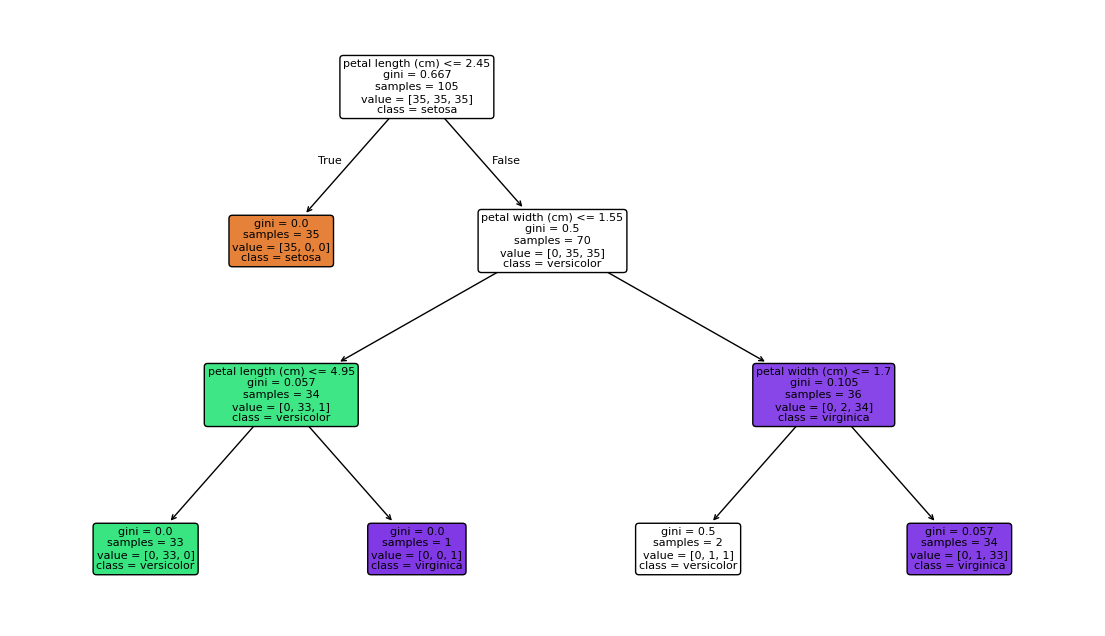

In [28]:
tree_small = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_small.fit(X_train_i, y_train_i)

plt.figure(figsize=(14, 8))
plot_tree(tree_small,
          feature_names=feature_names_i,
          class_names=class_names_i,
          filled=True,
          rounded=True,
          fontsize=8)
plt.show()

**Задание 1.3.**  
1. Прочитайте два-три пути от корня до листа и сформулируйте правила вида "если ... то ...".  
2. Какой признак чаще всего встречается на верхних уровнях дерева (более важный для разбиения)?

Ответ на задание 1.3

По дереву можно записать такие правила:

если petal length маленькая, то это почти всегда setosa.

если petal length больше, но petal width не очень большая, то чаще получается versicolor.

если petal width достаточно большая, то модель обычно относит цветок к virginica.

На верхних уровнях чаще всего встречаются признаки, связанные с лепестками: petal length и petal width. Значит, именно они сильнее всего помогают разделять классы.


### 1.2 Влияние глубины дерева на качество

Посмотрим, как меняется точность на train и test при разных `max_depth`.

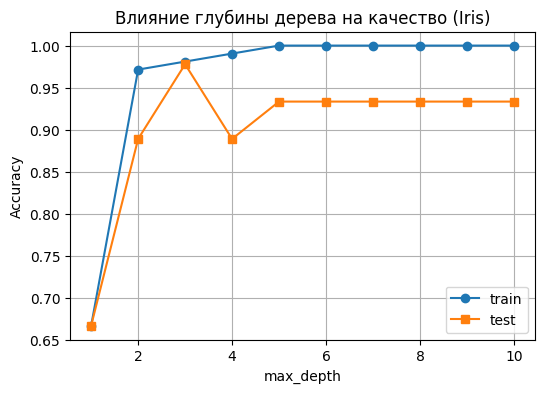

In [29]:
depths = range(1, 11)
train_scores = []
test_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train_i, y_train_i)
    train_scores.append(accuracy_score(y_train_i, clf.predict(X_train_i)))
    test_scores.append(accuracy_score(y_test_i, clf.predict(X_test_i)))

plt.figure(figsize=(6, 4))
plt.plot(depths, train_scores, marker="o", label="train")
plt.plot(depths, test_scores, marker="s", label="test")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Влияние глубины дерева на качество (Iris)")
plt.legend()
plt.grid(True)
plt.show()

**Задание 1.4.**  
1. При каких значениях глубины дерево переобучается (train≈1.0, test падает)?  
2. Какой диапазон глубин кажется вам разумным компромиссом между качеством и простотой модели?

Ответ на задание 1.4

Когда глубина становится большой, качество на train быстро доходит почти до 1.0, а на test уже может не расти или даже проседать. Это и есть признак переобучения: модель слишком подстраивается под обучающие данные.

Нормальным компромиссом мне кажется глубина примерно 2–4. Модель ещё достаточно простая, её можно понять, и качество при этом остаётся хорошим.


### 1.3. Random Forest и ROC/PR-кривые для Iris (one-vs-rest)

Теперь обучим случайный лес и построим ROC- и PR-кривые в схеме one-vs-rest для каждого класса.


Random Forest (Iris)
Accuracy: 0.9111111111111111
Confusion matrix:  [[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]
Classification report:                precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



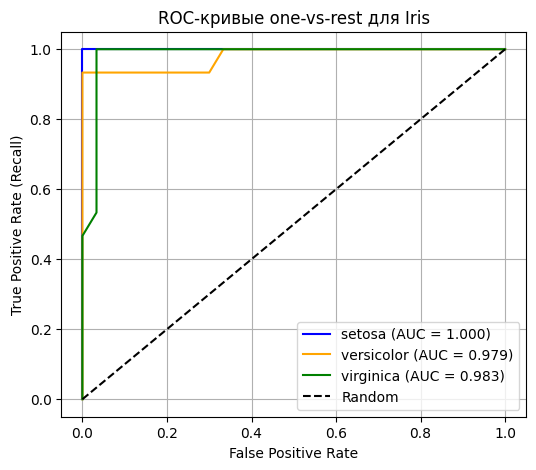

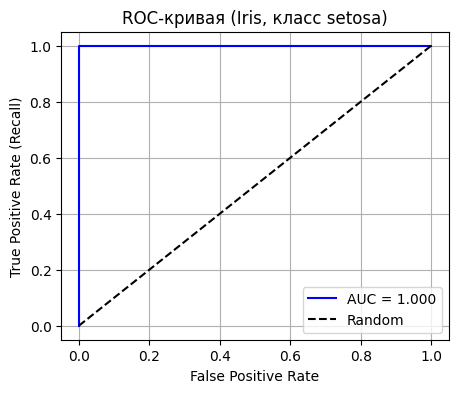

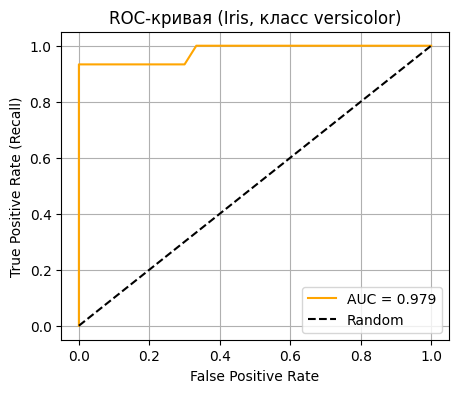

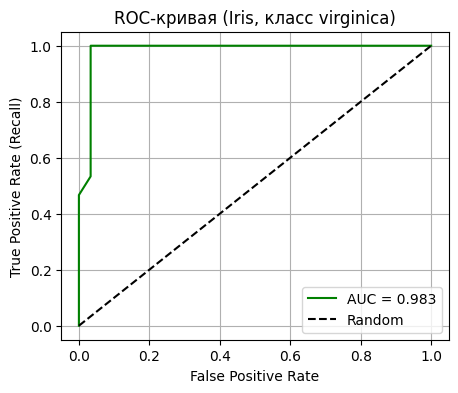

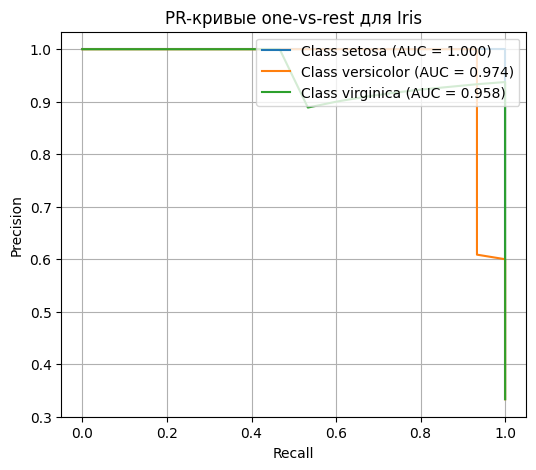

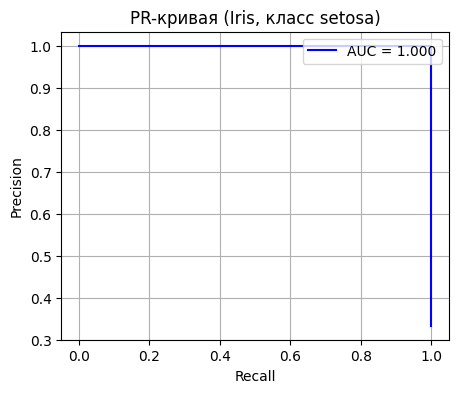

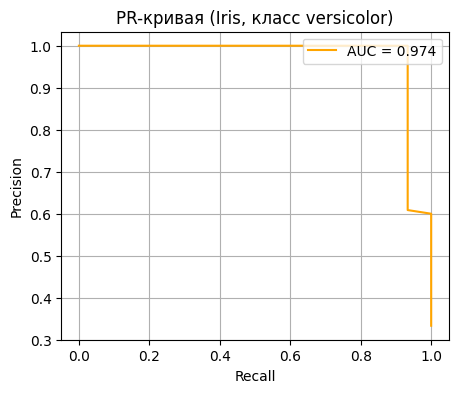

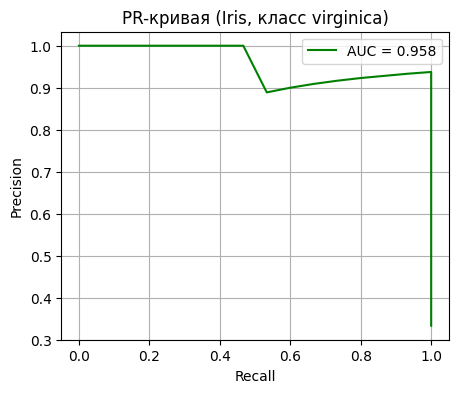

In [30]:
rf_iris = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_iris.fit(X_train_i, y_train_i)

y_pred_rf_i = rf_iris.predict(X_test_i)

y_proba_i = rf_iris.predict_proba(X_test_i)

print("Random Forest (Iris)")
print("Accuracy:", accuracy_score(y_test_i, y_pred_rf_i))
print("Confusion matrix: ", confusion_matrix(y_test_i, y_pred_rf_i))
print("Classification report: ",
      classification_report(y_test_i, y_pred_rf_i, target_names=class_names_i))

# ROC и PR one-vs-rest
classes = np.unique(y_test_i)
y_test_bin = label_binarize(y_test_i, classes=classes)

from sklearn.preprocessing import label_binarize

# Цвета для классов Iris
color_map = {
    0: 'blue',    # setosa
    1: 'orange',  # versicolor
    2: 'green',   # virginica
}

classes = np.unique(y_test_i)
y_test_bin = label_binarize(y_test_i, classes=classes)

plt.figure(figsize=(6, 5))
roc_aucs = []

for cls in classes:
    fpr, tpr, _ = roc_curve(y_test_bin[:, cls], y_proba_i[:, cls])
    roc_auc = auc(fpr, tpr)
    roc_aucs.append(roc_auc)

    plt.plot(
        fpr,
        tpr,
        color=color_map[cls],
        label=f'{class_names_i[cls]} (AUC = {roc_auc:.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-кривые one-vs-rest для Iris')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# ROC-кривые one-vs-rest по отдельным графикам

from sklearn.preprocessing import label_binarize

# Цвета для классов Iris
color_map = {
    0: 'blue',    # setosa
    1: 'orange',  # versicolor
    2: 'green',   # virginica
}

for cls in classes:
    fpr, tpr, _ = roc_curve(y_test_bin[:, cls], y_proba_i[:, cls])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(
        fpr,
        tpr,
        color=color_map[cls],
        label=f'AUC = {roc_auc:.3f}'
    )
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title(f'ROC-кривая (Iris, класс {class_names_i[cls]})')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# PR-кривые
plt.figure(figsize=(6, 5))
pr_aucs = []
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_i[:, i])
    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)
    plt.plot(recall, precision, label=f"Class {class_names_i[cls]} (AUC = {pr_auc:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривые one-vs-rest для Iris')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# PR-кривые one-vs-rest по отдельным графикам
for cls in classes:
    precision, recall, _ = precision_recall_curve(y_test_bin[:, cls], y_proba_i[:, cls])
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(5, 4))
    plt.plot(
        recall,
        precision,
        color=color_map[cls],
        label=f'AUC = {pr_auc:.3f}'
    )
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR-кривая (Iris, класс {class_names_i[cls]})')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()


## Задания для самостоятельной работы (Iris)

1. **Анализ структуры данных Iris**  
   1.1. Посчитайте количество объектов каждого класса (setosa, versicolor, virginica).  
   1.2. Выведите долю каждого класса в выборке.  
   1.3. Сделайте вывод: является ли задача по Iris сбалансированной? Как это отличается от задачи Titanic?

2. **Сравнение дерева решений и случайного леса**  
   2.1. Обучите `DecisionTreeClassifier` и `RandomForestClassifier` на одинаковых обучающих и тестовых выборках по Iris.  
   2.2. Для обеих моделей выведите:  
   - accuracy;  
   - confusion matrix;  
   - `classification_report` с `target_names=['setosa','versicolor','virginica']`.  
   2.3. Сравните результаты: какая модель лучше различает классы Iris? По каким метрикам вы делаете вывод?

3. **One-vs-rest ROC-кривые для Iris**  
   3.1. Для обученной модели (например, `rf_iris`) получите вероятности классов на тестовой выборке: `y_proba_i = rf_iris.predict_proba(X_test_i)`.  
   3.2. Постройте ROC-кривые в схеме one-vs-rest для каждого класса.  
   3.3. Выпишите значения AUC ROC для каждого класса.  
   3.4. Ответьте на вопросы:  
   - для какого класса AUC ROC максимален, а для какого — минимален;  
   - что это говорит о том, какие виды ирисов модель различает лучше/хуже.

4. **One-vs-rest PR-кривые для Iris**  
   4.1. Постройте PR-кривые (precision–recall) в схеме one-vs-rest для каждого класса, используя те же `y_test_i` и `y_proba_i`.  
   4.2. Вычислите AUC по PR для каждого класса.  
   4.3. Сравните AUC ROC и AUC PR для каждого класса:  
   - совпадает ли порядок «сложности» классов по ROC и по PR;  
   - есть ли классы, для которых PR-кривая даёт более строгую оценку, чем ROC?

5. **Анализ ошибок модели по confusion matrix**  
   5.1. Выберите лучшую модель для Iris (по вашему мнению) — дерево или лес.  
   5.2. Постройте confusion matrix для этой модели.  
   5.3. Ответьте:  
   - какие пары классов путаются чаще всего (например, versicolor ↔ virginica);  
   - с какими классами у модели нет проблем (почти нет ошибок).  
   5.4. Объясните, почему, с точки зрения геометрии признаков, именно эти классы труднее разделить (используйте знание о распределении признаков Iris).


Ответы на самостоятельную работу по Iris

1. В Iris всего 150 объектов: setosa — 50, versicolor — 50, virginica — 50. Доли классов одинаковые, по 0.333 на каждый класс. Поэтому задача Iris сбалансированная. В Titanic баланс уже хуже: после удаления пропусков погибших 424, а выживших 290, то есть примерно 59.4% против 40.6%.

2. На одинаковом разбиении дерево решений дало accuracy 0.933, а Random Forest — 0.911. По этим конкретным результатам дерево получилось немного лучше. У дерева macro avg F1 примерно 0.93, у леса примерно 0.91. Но разница небольшая, и на другом разбиении Random Forest вполне мог бы оказаться лучше. Setosa обе модели определяют идеально, а ошибки в основном появляются между versicolor и virginica.

3. Для Random Forest по Iris ROC AUC получился такой: setosa — 1.000, versicolor — 0.979, virginica — 0.983. Самый простой класс — setosa, потому что он очень хорошо отделяется. Самый слабый результат здесь у versicolor, но всё равно качество высокое.

4. PR AUC получился примерно такой: setosa — 1.000, versicolor — 0.974, virginica — 0.958. По PR видно почти то же самое: setosa определяется лучше всего, а versicolor/virginica сложнее. PR-кривая здесь не так критична, потому что классы сбалансированы, но она всё равно показывает, где модель менее уверенная.

5. Я бы для Iris выбрал дерево решений, потому что в этом запуске оно дало accuracy 0.933 против 0.911 у Random Forest. По confusion matrix видно, что setosa вообще не вызывает проблем. Чаще всего путаются versicolor и virginica, потому что их признаки ближе друг к другу. С точки зрения геометрии данных setosa находится отдельно, а versicolor и virginica частично пересекаются по длине и ширине лепестков.


## 2. Дерево решений и Random Forest на Titanic

Рассмотрим ещё одну классическую задачу: прогноз выживания пассажиров Титаника. Это бинарная классификация, где классы могут быть несбалансированы.

Мы используем встроенный датасет из библиотеки `seaborn`.

### 2.1. Загрузка и предобработка данных


In [35]:
import seaborn as sns

titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Датасет содержит, в числе прочего, следующие признаки:

- `survived` — целевая переменная (1 — выжил, 0 — нет);
- `pclass` — класс каюты (1, 2, 3);
- `sex` — пол;
- `age` — возраст;
- `fare` — цена билета;
- `alone` — был ли пассажир один.

In [43]:
# Размер датасета
titanic.shape

(891, 15)

In [44]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### 5.1 Подготовка данных

Оставим несколько простых признаков и удалим строки с пропусками в важных колонках.

In [45]:
# Упростим набор признаков
cols = ['survived', 'pclass', 'age', 'fare', 'sex', 'alone']
data_t = titanic[cols].dropna()

# Кодирование пола
data_t['sex_male'] = (data_t['sex'] == 'male').astype(int)

X_t = data_t[['pclass', 'age', 'fare', 'alone', 'sex_male']]
y_t = data_t['survived']

print(' Размер X_t:', X_t.shape)
print('Размер y_t:', y_t.shape)
print(' Распределение классов:')
print(y_t.value_counts())
print(' Доли классов:')
print(y_t.value_counts(normalize=True).round(3))


 Размер X_t: (714, 5)
Размер y_t: (714,)
 Распределение классов:
survived
0    424
1    290
Name: count, dtype: int64
 Доли классов:
survived
0    0.594
1    0.406
Name: proportion, dtype: float64


### 2.2. Обучение дерева решений и Random Forest


### 5.2 Дерево решений на Titanic

In [46]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t, test_size=0.3, random_state=42, stratify=y_t
)

# Дерево решений
dt_titanic = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_titanic.fit(X_train_t, y_train_t)

y_pred_dt_t = dt_titanic.predict(X_test_t)

print('Дерево решений (Titanic)')
print('Accuracy:', accuracy_score(y_test_t, y_pred_dt_t))
print('Confusion matrix: ', confusion_matrix(y_test_t, y_pred_dt_t))
print('Classification report: ', classification_report(y_test_t, y_pred_dt_t))


Дерево решений (Titanic)
Accuracy: 0.7953488372093023
Confusion matrix:  [[101  27]
 [ 17  70]]
Classification report:                precision    recall  f1-score   support

           0       0.86      0.79      0.82       128
           1       0.72      0.80      0.76        87

    accuracy                           0.80       215
   macro avg       0.79      0.80      0.79       215
weighted avg       0.80      0.80      0.80       215



**Задание 5.1.**

1. Какое качество даёт дерево решений на задаче Титаника?  
2. Как оно соотносится с качеством на кредитном скоринге и болезни растений?

Ответ на задание 5.1

Дерево решений на Titanic дало accuracy примерно 0.795, то есть около 80%. По матрице ошибок видно, что модель правильно нашла 101 погибшего и 70 выживших, но ошиблась на 27 погибших и 17 выживших.

Если сравнивать с кредитным скорингом и болезнью растений, то тут ситуация немного другая. В Titanic дисбаланс есть, но не такой сильный: выживших около 40.6%, погибших около 59.4%. Поэтому accuracy здесь выглядит более честно, чем в задачах, где положительный класс очень редкий. В кредитах и особенно в болезнях растений можно получить высокую accuracy просто за счёт угадывания большинства, поэтому там важнее смотреть precision, recall, F1 и PR-кривую.


### 5.3 Random Forest на Titanic

In [47]:
# Random Forest
rf_titanic = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_titanic.fit(X_train_t, y_train_t)

y_pred_rf_t = rf_titanic.predict(X_test_t)

print(' Random Forest (Titanic)')
print('Accuracy:', accuracy_score(y_test_t, y_pred_rf_t))
print('Confusion matrix: ', confusion_matrix(y_test_t, y_pred_rf_t))
print('Classification report: ', classification_report(y_test_t, y_pred_rf_t))

 Random Forest (Titanic)
Accuracy: 0.772093023255814
Confusion matrix:  [[105  23]
 [ 26  61]]
Classification report:                precision    recall  f1-score   support

           0       0.80      0.82      0.81       128
           1       0.73      0.70      0.71        87

    accuracy                           0.77       215
   macro avg       0.76      0.76      0.76       215
weighted avg       0.77      0.77      0.77       215



**Задание 5.2. Интерпретация Titanic**

1. Какие признаки оказываются наиболее важными для прогноза выживания?  
2. Соответствуют ли эти результаты вашим ожиданиям (например, более высокий класс, женский пол, более высокая стоимость билета)?  
3. Сравните относительную важность признаков на Titanic и на кредитном датасете: какие закономерности похожи, а какие — принципиально другие?

Ответ на задание 5.2

По важности признаков у дерева самым главным оказался sex_male, потом pclass, age и fare. У Random Forest важность распределилась немного иначе: fare и age стали очень заметными, потом sex_male и pclass, а alone почти не влияет.

В целом это совпадает с ожиданиями. На Титанике шанс выжить сильно зависел от пола, класса билета, возраста и стоимости билета. То есть женщинам, пассажирам более высокого класса и тем, у кого был более дорогой билет, модель чаще даёт больший шанс выживания.

С кредитным датасетом закономерность другая. Там признаки обычно связаны с финансовым поведением человека: доход, долги, просрочки, история платежей. В Titanic признаки больше социальные и демографические: пол, возраст, класс, цена билета. Похоже только то, что и там и там модель ищет признаки, которые сильнее всего меняют вероятность целевого класса.


### 2.3. ROC AUC и PR-кривая для Titanic (RandomForestClassifier)


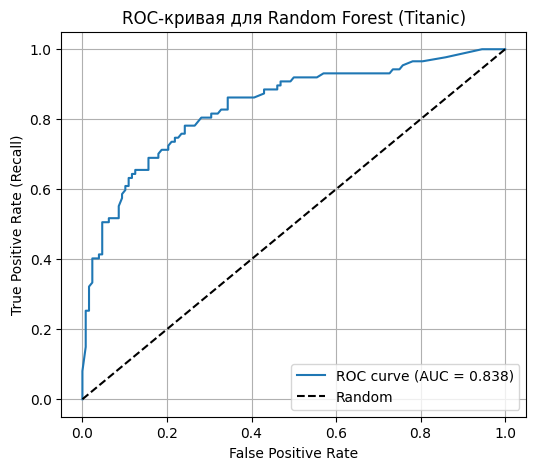

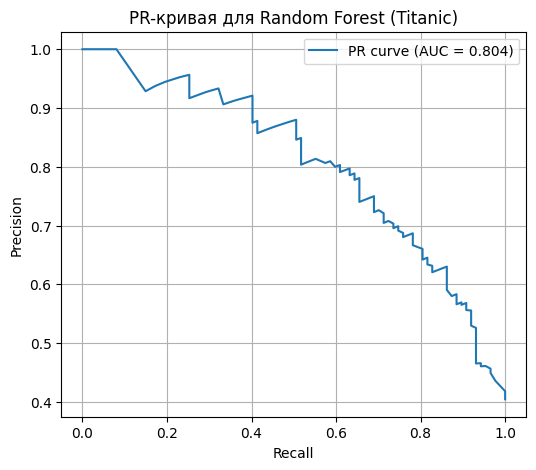

In [48]:
# ROC AUC и PR AUC для Titanic

# Вероятности положительного класса (выжил)
y_proba_t = rf_titanic.predict_proba(X_test_t)[:, 1]

# ROC-кривая
fpr, tpr, roc_thresholds = roc_curve(y_test_t, y_proba_t)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-кривая для Random Forest (Titanic)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# PR-кривая
precision_t, recall_t, pr_thresholds_t = precision_recall_curve(y_test_t, y_proba_t)
pr_auc_t = auc(recall_t, precision_t)

plt.figure(figsize=(6, 5))
plt.plot(recall_t, precision_t, label=f'PR curve (AUC = {pr_auc_t:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривая для Random Forest (Titanic)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


# Демонстрация усиленного дисбаланса и ROC/PR для новой выборки

Распределение классов (усиленный дисбаланс):
survived
0    424
1     58
Name: count, dtype: int64

Доли классов:
survived
0    0.88
1    0.12
Name: proportion, dtype: float64

Random Forest (усиленный дисбаланс)
Accuracy: 0.9310344827586207
Confusion matrix:
 [[124   4]
 [  6  11]]
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       128
           1       0.73      0.65      0.69        17

    accuracy                           0.93       145
   macro avg       0.84      0.81      0.82       145
weighted avg       0.93      0.93      0.93       145



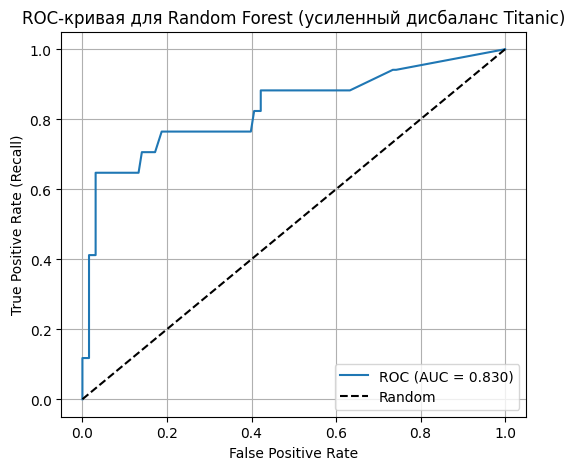

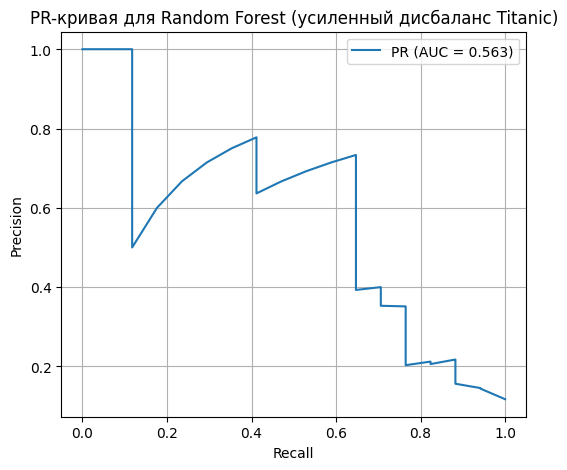

Доля положительного класса (оригинальный Titanic): 0.406
Доля положительного класса (усиленный дисбаланс): 0.12
Это приблизительный базовый уровень PR AUC для случайного классификатора.


In [40]:
# 1. Усиливаем дисбаланс: оставляем всех погибших и только часть выживших
maj = data_t[data_t['survived'] == 0]
min_all = data_t[data_t['survived'] == 1]

# Оставим, например, 20% выживших
min_small = min_all.sample(frac=0.2, random_state=42)
data_imb = pd.concat([maj, min_small], axis=0)

X_imb = data_imb[['pclass', 'age', 'fare', 'alone', 'sex_male']]
y_imb = data_imb['survived']

print('Распределение классов (усиленный дисбаланс):')
print(y_imb.value_counts())
print('\nДоли классов:')
print(y_imb.value_counts(normalize=True).round(3))

# 2. Разделение на обучающую и тестовую выборки
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

# 3. Обучение Random Forest на несбалансированных данных
rf_imb = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_imb.fit(X_train_imb, y_train_imb)

y_pred_imb = rf_imb.predict(X_test_imb)
y_proba_imb = rf_imb.predict_proba(X_test_imb)[:, 1]

print('\nRandom Forest (усиленный дисбаланс)')
print('Accuracy:', accuracy_score(y_test_imb, y_pred_imb))
print('Confusion matrix:\n', confusion_matrix(y_test_imb, y_pred_imb))
print('Classification report:\n', classification_report(y_test_imb, y_pred_imb))

# 4. ROC-кривая
fpr_imb, tpr_imb, _ = roc_curve(y_test_imb, y_proba_imb)
roc_auc_imb = auc(fpr_imb, tpr_imb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_imb, tpr_imb, label=f'ROC (AUC = {roc_auc_imb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-кривая для Random Forest (усиленный дисбаланс Titanic)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 5. PR-кривая
precision_imb, recall_imb, _ = precision_recall_curve(y_test_imb, y_proba_imb)
pr_auc_imb = auc(recall_imb, precision_imb)

plt.figure(figsize=(6, 5))
plt.plot(recall_imb, precision_imb, label=f'PR (AUC = {pr_auc_imb:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривая для Random Forest (усиленный дисбаланс Titanic)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# 6. Базовый уровень для PR по доле положительного класса
pos_rate_orig = y_t.mean()
pos_rate_imb = y_imb.mean()
print('Доля положительного класса (оригинальный Titanic):', round(pos_rate_orig, 3))
print('Доля положительного класса (усиленный дисбаланс):', round(pos_rate_imb, 3))
print('Это приблизительный базовый уровень PR AUC для случайного классификатора.')

## Задания для самостоятельной работы (Titanic)

1. **Анализ баланса классов**  
   1.1. Посчитайте количество выживших и погибших пассажиров в обучающем наборе.  
   1.2. Выведите долю выживших.  
   1.3. Сделайте вывод: является ли задача сбалансированной или наблюдается дисбаланс классов?

2. **Сравнение дерева решений и случайного леса**  
   2.1. Обучите `DecisionTreeClassifier` и `RandomForestClassifier` на одинаковых обучающих и тестовых выборках по Titanic (с тем же набором признаков, что в ноутбуке).  
   2.2. Для обеих моделей выведите:  
   - accuracy;  
   - confusion matrix;  
   - `classification_report`.  
   2.3. Сравните результаты: какая модель лучше различает класс «выжил»? Объясните, по каким метрикам вы делаете вывод.

3. **ROC AUC для Titanic**  
   3.1. Для модели `RandomForestClassifier` по Titanic получите вероятности класса «выжил» (`predict_proba`).  
   3.2. Постройте ROC-кривую и вычислите ROC AUC.  
   3.3. На графике отметьте точку, соответствующую стандартному порогу 0.5.  
   3.4. Сделайте вывод:  
   - какова площадь под ROC-кривой (близка ли она к 1);  
   - что это означает в терминах «насколько модель хорошо отделяет выживших от погибших».

4. **PR-кривая и сравнение с ROC**  
   4.1. Постройте PR-кривую (precision–recall) для той же модели и тех же вероятностей.  
   4.2. Вычислите площадь под PR-кривой (PR AUC).  
   4.3. Объясните:  
   - в чём отличие интерпретации ROC и PR-кривых;  
   - почему PR-кривая может быть более информативной, если класс «выжил» менее многочисленен, чем «погиб».

5. **Выбор порога по PR-кривой**  
   5.1. Для нескольких порогов (например, 0.3, 0.4, 0.5, 0.6) вычислите precision, recall и F1-меру для класса «выжил».  
   5.2. Представьте результаты в виде таблицы (строки — пороги, столбцы — метрики).  
   5.3. Используя PR-кривую и таблицу, выберите «разумный» порог для задачи Titanic (обоснуйте: что важнее — не пропустить выживших или не давать слишком много ложных «выжил»).  
   5.4. Сформулируйте вывод в терминах: «если бы мы использовали эту модель для эвакуации, какой порог был бы допустим и почему».

6. **Стратифицированная кросс-валидация**  
   6.1. Постройте `StratifiedKFold` с 5 фолдами для Random Forest по Titanic.  
   6.2. Оцените модель по метрике F1 (для класса «выжил») с помощью `cross_val_score`.  
   6.3. Выведите значения F1 по фолдам и среднее значение.  
   6.4. Объясните, почему F1 для класса «выжил» может быть полезнее, чем просто средняя accuracy по фолдам, особенно если классы несбалансированы.

7. **Анализ ошибок модели**  
   7.1. Выберите «лучшую» модель и порог (по вашим критериям из предыдущих заданий).  
   7.2. Найдите 5–10 пассажиров, которых модель:  
   - ошибочно предсказала как «выжил», хотя они погибли (FP);  
   - ошибочно предсказала как «погиб», хотя они выжили (FN).  
   7.3. Попробуйте описать, какие признаки могли привести к этим ошибкам (класс билета, пол, возраст, стоимость билета и т.п.).  
   7.4. Предложите, какие дополнительные признаки могли бы улучшить модель (например, группировка по семье, размер каюты и т.п.).


Ответы на самостоятельную работу по Titanic

1. В обучающем наборе получилось 296 погибших и 203 выживших. Доля выживших примерно 0.407. Значит, дисбаланс есть, но он умеренный. Это не ситуация 99 на 1, но классы всё равно не равные.

2. Дерево решений показало accuracy 0.795, Random Forest — 0.772. Для класса «выжил» у дерева recall 0.80 и F1 0.76, а у Random Forest recall 0.70 и F1 0.71. Поэтому в этом запуске дерево лучше различает выживших, хотя обычно лес часто бывает стабильнее. Тут конкретно дерево оказалось удачнее.

3. Для Random Forest ROC AUC получился примерно 0.838. Это не идеально, но заметно лучше случайной модели, у которой было бы около 0.5. Значит, модель в целом умеет отделять выживших от погибших, просто не без ошибок.

4. PR AUC для Random Forest получился примерно 0.804. ROC показывает, насколько хорошо модель разделяет классы в целом, а PR больше смотрит на качество по положительному классу, то есть по «выжил». Для Titanic PR-кривая полезна, потому что выживших меньше, чем погибших, и важно понимать, насколько точно модель находит именно их.

5. По порогам получилось так: при 0.3 precision около 0.654, recall около 0.805, F1 около 0.722; при 0.4 precision около 0.688, recall около 0.759, F1 около 0.721; при 0.5 precision около 0.726, recall около 0.701, F1 около 0.713; при 0.6 precision около 0.760, recall около 0.655, F1 около 0.704. Я бы выбрал порог 0.4, потому что он сохраняет достаточно высокий recall и при этом precision не слишком низкий. Если думать про эвакуацию, лучше лишний раз ошибочно посчитать человека выжившим/нуждающимся в помощи, чем пропустить того, кто реально выжил. Поэтому слишком высокий порог тут не очень подходит.

6. При StratifiedKFold на 5 фолдах F1 для класса «выжил» получился примерно так: 0.774, 0.734, 0.716, 0.783, 0.783. Среднее около 0.758. F1 полезнее простой accuracy, потому что он учитывает и precision, и recall. Если классы несбалансированы, accuracy может выглядеть нормально, даже когда модель плохо находит меньший класс.

7. Лучшей моделью я бы выбрал дерево решений или Random Forest с пониженным порогом около 0.4, если цель — лучше находить выживших. Ошибки FP могут появляться у пассажиров, которые по признакам похожи на выживших: например, высокий класс или дорогой билет, но фактически они погибли. Ошибки FN могут быть у тех, кто выжил, но по признакам похож на погибших: например, мужчина, 3 класс, низкая стоимость билета. Улучшить модель могли бы дополнительные признаки: размер семьи, наличие родственников рядом, палуба/каюта, порт посадки, обращение из имени типа Mr/Mrs/Miss, а ещё признаки групп пассажиров.


## 3. Итоговые вопросы

1. В чём принципиальная идея дерева решений как модели классификации?  
   
2. Как ограничения `max_depth`, `min_samples_leaf` и другие параметры помогают бороться с переобучением дерева?  
   
3. Почему ансамбли деревьев (Random Forest, Gradient Boosting) обычно дают лучшее качество, чем одиночное дерево? 

4. Сравните суммарно ROC- и PR-кривые для Iris и Titanic:  
   - чем отличается интерпретация ROC/PR при сбалансированных классах (Iris) и при несбалансированных (Titanic);  
   - в какой задаче PR-кривые дают более важную информацию, чем ROC, и почему.

5. Сформулируйте общий вывод:  
   «Когда для оценки качества классификации достаточно ROC AUC, а когда обязательно смотреть и PR-кривую?»

6. Какие выводы о выборе модели (дерево vs Random Forest) вы можете сделать для Iris и для Titanic?


Ответы на итоговые вопросы

1. Дерево решений работает как набор простых вопросов. Например: если признак меньше какого-то значения — идём влево, если больше — вправо. В конце попадаем в лист, где модель выбирает класс.

2. max_depth, min_samples_leaf и похожие параметры не дают дереву слишком сильно разрастаться. Если дерево слишком глубокое, оно может запомнить обучающую выборку вместе со случайными особенностями. Ограничения заставляют модель делать более общие правила, а не подстраиваться под каждый отдельный объект.

3. Ансамбли деревьев обычно лучше одиночного дерева, потому что они объединяют много моделей. Одно дерево может ошибиться из-за случайного разбиения данных, а лес усредняет ответы многих деревьев. Поэтому результат часто получается стабильнее.

4. В Iris классы сбалансированы, поэтому ROC и PR читаются довольно спокойно: каждый класс представлен одинаково, и accuracy тоже достаточно понятна. В Titanic классы уже не равны, особенно если специально усилить дисбаланс. Там ROC может выглядеть нормально, но PR важнее показывает, насколько хорошо модель находит именно положительный класс, то есть выживших.

5. ROC AUC обычно достаточно смотреть, когда классы примерно сбалансированы и нам важно общее разделение классов. PR-кривую обязательно стоит смотреть, когда положительный класс редкий или особенно важный. Например, болезнь, дефолт, мошенничество, выжившие и так далее. В таких задачах важно не только «в целом хорошо», а именно насколько качественно модель ловит нужный класс.

6. Для Iris в этом запуске дерево решений даже немного лучше Random Forest, и его проще объяснить. Для Titanic дерево тоже показало чуть лучшее качество по accuracy и F1 для выживших, но Random Forest остаётся полезным, потому что он обычно устойчивее и позволяет смотреть вероятности и важность признаков. В целом нельзя автоматически говорить, что лес всегда лучше: надо сравнивать по метрикам на конкретной задаче.
